# 02 — Comprehensive EDA (ARMD)  ·  *decision-support, nothing assumed*

Goal: understand the data well enough to **decide** — later, not now — what the graph nodes,
edges, prediction target, and federated split should be. This notebook **surveys and reports**;
it does not lock anything.

| Part | What it answers | Decision it informs |
|---|---|---|
| 0 | Setup + load helpers | — |
| 1 | Table inventory, join integrity, grain/fan-out | how to join / aggregate |
| 2 | The label: raw counts + target framings | binary vs 3-class vs drop rules |
| 3 | Entity cardinality + cross-patient sharing | **which entities become NODES vs features** |
| 4 | Relationship survey + degree distributions | **which EDGES to build** |
| 5 | Feature availability + null rates + distributions | which features are usable |
| 6 | Candidate split strategies compared | **how to split into 'hospitals'** |
| 7 | Per-partition structural preview | sanity-check a chosen split |
| 8 | Neutral readout | your call sheet |

> Data is not committed. Set `ARMD_DIR` to your Drive mount before running.
> Set `SAMPLE_N` (below) to a number for a fast first pass, then `None` for the full run.


## Part 0 — Setup & loaders


In [3]:
import sys, os, re
from pathlib import Path

for _p in [Path.cwd(), Path.cwd().parent]:
    if (_p / "src").exists():
        sys.path.insert(0, str(_p / "src")); break

# If your kernel didn't inherit ARMD_DIR from ~/.zshrc, set it here BEFORE importing config,
# then restart the kernel:
# os.environ["ARMD_DIR"] = "/Users/you/Library/CloudStorage/GoogleDrive-.../ARMD"

from amr_fed import config
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
np.random.seed(config.SEED)

SAMPLE_N = 200000   # e.g. 200_000 for a quick dry run; None = full data

DATA_DIR = Path(config.DATA_DIR)
print("DATA_DIR:", DATA_DIR, "| exists:", DATA_DIR.exists(), "| SAMPLE_N:", SAMPLE_N)

DATA_DIR: /Users/vsharma4/Library/CloudStorage/GoogleDrive-vsharma4@g2.com/.shortcut-targets-by-id/1uVx5PmldPyJBMtnB9Lkl9N1rNBQrmJt-/ARMD | exists: True | SAMPLE_N: 200000


In [4]:
# --- factual constants from config (file names, join keys, verified column names) ---
KEYS = list(config.KEYS.values())
PK, CK = config.KEYS["patient"], config.KEYS["culture"]
ORG, ABX = config.COLUMNS["organism"], config.COLUMNS["antibiotic"]
LABEL = config.LABEL_COLUMN

def path_for(name): return DATA_DIR / config.ARMD_TABLES[name]

def cols_of(name):
    fp = path_for(name)
    return pd.read_csv(fp, nrows=0).columns.tolist() if fp.exists() else []

def load(name, usecols=None, nrows=SAMPLE_N):
    fp = path_for(name)
    if not fp.exists():
        print(f"  [skip] {name}: not found ({fp.name})"); return None
    if usecols is not None:
        have = set(cols_of(name)); miss = [c for c in usecols if c not in have]
        if miss: print(f"  [warn] {name}: missing {miss}")
        usecols = [c for c in usecols if c in have] or None
    return pd.read_csv(fp, usecols=usecols, nrows=nrows, low_memory=False)

def find_cols(name, *substrings):
    """Return columns in a table whose name contains any given substring (schema-drift proof)."""
    cs = cols_of(name)
    return [c for c in cs if any(s.lower() in c.lower() for s in substrings)]

print("Availability:")
for n in config.ARMD_TABLES:
    print(f"  {n:14s} {'OK ' if path_for(n).exists() else 'MISSING'}  {config.ARMD_TABLES[n]}")

Availability:
  cohort         OK   microbiology_cultures_cohort.csv
  demographics   OK   microbiology_cultures_demographics.csv
  adi            OK   microbiology_cultures_adi_scores.csv
  comorbidity    OK   microbiology_cultures_comorbidity.csv
  procedures     OK   microbiology_cultures_priorprocedures.csv
  ward           OK   microbiology_cultures_ward_info.csv
  labs           OK   microbiology_cultures_labs.csv
  vitals         OK   microbiology_cultures_vitals.csv
  abx_class_exp  OK   microbiology_cultures_antibiotic_class_exposure.csv
  resistance     OK   microbiology_cultures_microbial_resistance.csv


## Part 1 — Table inventory, join integrity & grain

For each table: size, columns, its **grain** (rows per culture-order), and how well it joins
back to the cohort. `rows_per_culture > 1` means the table **fans out** — you must aggregate it
before its contents can become node/edge features.


In [5]:
inv = []
for name in config.ARMD_TABLES:
    cs = cols_of(name)
    if not cs: continue
    ks = [k for k in KEYS if k in cs]
    df = load(name, usecols=ks) if ks else load(name, usecols=cs[:1])
    row = {"table": name, "n_cols": len(cs), "rows": len(df) if df is not None else None}
    if df is not None and CK in df.columns:
        row["uniq_cultures"] = df[CK].nunique()
        row["rows_per_culture"] = round(len(df)/max(df[CK].nunique(),1), 2)
    if df is not None and PK in df.columns:
        row["uniq_patients"] = df[PK].nunique()
    inv.append(row)
inventory = pd.DataFrame(inv).set_index("table")
inventory

,n_cols,rows,uniq_cultures,rows_per_culture,uniq_patients
table,,,,,
cohort,10,200000,134320,1.49,85867
demographics,5,200000,200000,1.00,71782
adi,6,200000,200000,1.00,83303
comorbidity,7,200000,133699,1.50,56858
procedures,6,200000,95132,2.10,30978
ward,8,200000,200000,1.00,114936
labs,59,200000,160977,1.24,97938
vitals,28,200000,118262,1.69,72653
abx_class_exp,8,200000,123753,1.62,45209


In [6]:
# Full column listing per table (so you can see everything available)
for name in config.ARMD_TABLES:
    cs = cols_of(name)
    if cs: print(f"\n### {name}  ({len(cs)} cols)\n", cs)


### cohort  (10 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility']

### demographics  (5 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'age', 'gender']

### adi  (6 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'adi_score', 'adi_state_rank']

### comorbidity  (7 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'comorbidity_component', 'comorbidity_component_start_days_culture', 'comorbidity_component_end_days_culture']

### procedures  (6 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'procedure_description', 'procedure_time_to_culturetime']

### ward  (8 cols)
 ['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'hosp_ward_IP', 'hosp_ward_OP', 'hosp_ward_ER

In [7]:
# Join coverage: fraction of cohort culture-orders present in each auxiliary table
base = set(load("cohort", usecols=[CK])[CK].unique())
cov = {}
for name in config.ARMD_TABLES:
    if name == "cohort": continue
    if CK not in cols_of(name): cov[name] = np.nan; continue
    cov[name] = round(len(base & set(load(name, usecols=[CK])[CK].unique()))/len(base), 3)
pd.Series(cov, name="frac_cohort_cultures_present").sort_values(ascending=False).to_frame()

,frac_cohort_cultures_present
ward,0.300
adi,0.268
demographics,0.216
comorbidity,0.191
abx_class_exp,0.188
labs,0.179
vitals,0.134
procedures,0.127
resistance,0.120


## Part 2 — The prediction label & target framings

ARMD's `susceptibility` has several values. This part shows the raw balance and lays out the
**target options** with row counts, so you can choose binary / 3-class / which rows to drop —
instead of it being pre-decided.


In [8]:
keep = [PK, CK, ORG, ABX, LABEL, config.COLUMNS["was_positive"], config.COLUMNS["culture_description"]]
if "ordering_mode" in cols_of("cohort"): keep.append("ordering_mode")
cohort = load("cohort", usecols=keep)
print("cohort shape:", cohort.shape)
print("\nRaw susceptibility counts:")
print(cohort[LABEL].value_counts(dropna=False))

cohort shape: (200000, 8)

Raw susceptibility counts:
susceptibility
Susceptible     117247
Null             53513
Resistant        24386
Intermediate      4412
Inconclusive       255
Synergism          187
Name: count, dtype: int64


In [9]:
# Which labels co-occur with negative cultures? (was_positive == 0)
wp = config.COLUMNS["was_positive"]
print(pd.crosstab(cohort[LABEL].fillna("NULL"), cohort[wp], dropna=False))
print("\n=> confirms whether 'Null' susceptibility == negative culture (no organism to test)")

was_positive        0       1
susceptibility               
Inconclusive        0     255
Intermediate        0    4412
Null            53164     349
Resistant           0   24386
Susceptible         0  117247
Synergism           0     187

=> confirms whether 'Null' susceptibility == negative culture (no organism to test)


In [10]:
# Target framings side by side (choose later, not now)
vc = cohort[LABEL].value_counts()
outcomes = ["Susceptible", "Resistant", "Intermediate"]
present = [x for x in outcomes if x in vc.index]
n_out = int(vc.reindex(present).sum())
def pct(n): return f"{n:,} ({n/len(cohort):.1%})"
print("Total cohort rows:", f"{len(cohort):,}\n")
print("Framing A  Binary R-vs-S, drop Intermediate & non-outcomes:")
print("   usable rows:", pct(int(vc.reindex(['Susceptible','Resistant']).sum())))
print("Framing B  Binary (R+I)-vs-S, drop only non-outcomes:")
print("   usable rows:", pct(n_out))
print("Framing C  3-class S/I/R:")
print("   usable rows:", pct(n_out), " -> classes:", {k:int(vc[k]) for k in present})
if all(x in vc.index for x in ['Susceptible','Resistant']):
    r = vc.get('Resistant',0)+vc.get('Intermediate',0); s = vc.get('Susceptible',0)
    print(f"\nImbalance (R+I : S) ~ 1 : {s/max(r,1):.1f}  -> class weights will be needed either way")

Total cohort rows: 200,000

Framing A  Binary R-vs-S, drop Intermediate & non-outcomes:
   usable rows: 141,633 (70.8%)
Framing B  Binary (R+I)-vs-S, drop only non-outcomes:
   usable rows: 146,045 (73.0%)
Framing C  3-class S/I/R:
   usable rows: 146,045 (73.0%)  -> classes: {'Susceptible': 117247, 'Resistant': 24386, 'Intermediate': 4412}

Imbalance (R+I : S) ~ 1 : 4.1  -> class weights will be needed either way


In [11]:
# Does resistance vary by specimen type? (early signal for a possible split axis, Part 6)
cd = config.COLUMNS["culture_description"]
tmp = cohort[cohort[LABEL].isin(outcomes)].copy()
tmp["is_R"] = tmp[LABEL].isin(["Resistant","Intermediate"]).astype(int)
by_spec = tmp.groupby(cd)["is_R"].agg(tests="size", resistant_rate="mean").sort_values("tests", ascending=False).head(12)
by_spec.round(3)

,tests,resistant_rate
culture_description,,
URINE,110682,0.177
RESPIRATORY,21136,0.285
BLOOD,14227,0.222


## Part 3 — Entity cardinality & the node-vs-feature question

For every candidate entity: how many distinct values, and how **shared across patients** it is.
Rule of thumb — an entity that many different patients connect to is a good **node**; something
that is essentially per-record is better as a **feature**. High distinct-count + long tail may
need an `Other` bucket. Nothing is decided here; the table gives you the basis to decide.


In [12]:
c2p = cohort[[CK, PK]].drop_duplicates()      # culture -> patient map for culture-keyed tables

def entity_stats(label, table, col):
    """distinct values, patient reach, sharing ratio, tail heaviness."""
    if table == "cohort":
        df = cohort[[PK, col]].dropna()
    else:
        if table not in config.ARMD_TABLES or col not in cols_of(table): return None
        raw = load(table, usecols=[CK, col])
        if raw is None: return None
        df = raw.merge(c2p, on=CK, how="left")[[PK, col]].dropna()
    n_val = df[col].nunique()
    reach = df.groupby(col)[PK].nunique()          # distinct patients per value
    vc = df[col].value_counts()
    return {"entity": label, "table": table, "distinct": n_val,
            "median_patients_per_value": int(reach.median()),
            "max_patients_per_value": int(reach.max()),
            "pct_values_seen_lt_50_patients": round((reach < 50).mean(), 3),
            "top1_share": round(vc.iloc[0]/vc.sum(), 3)}

candidates = [
    ("organism",        "cohort",       ORG),
    ("antibiotic",      "cohort",       ABX),
    ("specimen_type",   "cohort",       config.COLUMNS["culture_description"]),
    ("comorbidity",     "comorbidity",  config.COLUMNS["comorbidity"]),
    ("procedure",       "procedures",   config.COLUMNS["procedure"]),
    ("antibiotic_class","abx_class_exp","antibiotic_class"),
]
rows = [r for r in (entity_stats(*c) for c in candidates) if r]
catalog = pd.DataFrame(rows).set_index("entity")
print("High 'patients_per_value' + moderate 'distinct' => strong NODE candidate.")
print("Very high 'distinct' + heavy tail (pct_values_seen_lt_50_patients high) => bucket or use as feature.\n")
catalog

High 'patients_per_value' + moderate 'distinct' => strong NODE candidate.
Very high 'distinct' + heavy tail (pct_values_seen_lt_50_patients high) => bucket or use as feature.



,table,distinct,median_patients_per_value,max_patients_per_value,pct_values_seen_lt_50_patients,top1_share
entity,,,,,,
organism,cohort,264,6,44910,0.841,0.384
antibiotic,cohort,55,1031,44910,0.200,0.266
specimen_type,cohort,3,25139,58371,0.000,0.674
comorbidity,comorbidity,418,36,520,0.577,0.014
procedure,procedures,6,1278,6823,0.000,0.520
antibiotic_class,abx_class_exp,18,613,5334,0.056,0.229


patients: 85,867 | cultures/patient  mean=1.56  median=1  p95=4  max=66


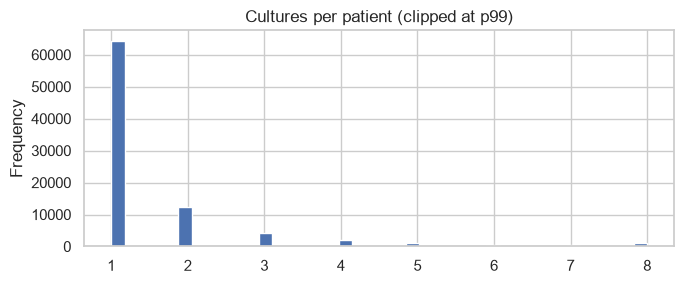

In [25]:
# Patient side: how many cultures per patient (graph sparsity on the patient side)
deg = cohort.groupby(PK)[CK].nunique()
print(f"patients: {deg.size:,} | cultures/patient  mean={deg.mean():.2f}  median={deg.median():.0f}  p95={deg.quantile(.95):.0f}  max={deg.max()}")
plt.figure(figsize=(7,3))
deg.clip(upper=deg.quantile(.99)).plot.hist(bins=40, title="Cultures per patient (clipped at p99)")
plt.tight_layout(); plt.show()

/var/folders/xy/h2c9cs9s0yx4p27j4f97zjr00000gp/T/ipykernel_12750/2282368510.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


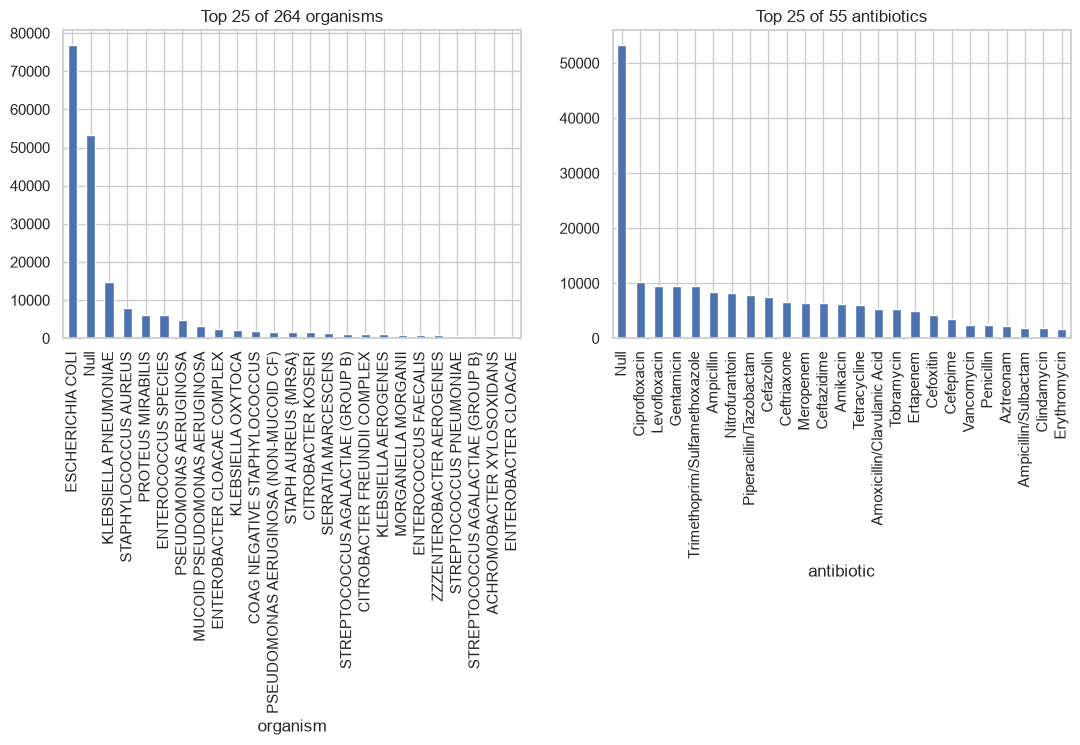

In [14]:
# Frequency curves for the two core entities (informs Other-bucket cutoffs)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cohort[ORG].value_counts().head(25).plot.bar(ax=ax[0], title=f"Top 25 of {cohort[ORG].nunique()} organisms")
cohort[ABX].value_counts().head(25).plot.bar(ax=ax[1], title=f"Top 25 of {cohort[ABX].nunique()} antibiotics")
plt.tight_layout(); plt.show()

## Part 4 — Relationship (edge) survey

Every candidate connection: how many distinct edges it yields and how skewed the degrees are.
Sparse/empty relationships aren't worth an edge type; hub nodes (e.g. E. coli) will need
neighbour-sampling caps in the GNN. Again: a survey, not a decision.


In [15]:
def edge_survey(label, left_df, a, b):
    e = left_df[[a, b]].dropna().drop_duplicates()
    if len(e) == 0: return None
    da = e.groupby(a).size(); db = e.groupby(b).size()
    return {"relationship": label, "distinct_edges": len(e),
            f"deg_{a}_median": int(da.median()), f"deg_{a}_max": int(da.max()),
            f"deg_{b}_median": int(db.median()), f"deg_{b}_max": int(db.max())}

rows = []
# organism <-> antibiotic (the natural prediction relationship)
r = edge_survey("organism~antibiotic (label lives here)", cohort, ORG, ABX)
if r: rows.append({k:r.get(k) for k in ["relationship","distinct_edges"]} | {"note":"target candidate"})
# patient <-> organism
e = cohort[[PK, ORG]].dropna().drop_duplicates(); rows.append({"relationship":"patient~organism","distinct_edges":len(e),"note":""})
# patient <-> comorbidity / procedure / antibiotic_class  (via culture->patient)
for lbl, tbl, col in [("patient~comorbidity","comorbidity",config.COLUMNS["comorbidity"]),
                      ("patient~procedure","procedures",config.COLUMNS["procedure"]),
                      ("patient~antibiotic_class","abx_class_exp","antibiotic_class")]:
    if tbl in config.ARMD_TABLES and col in cols_of(tbl):
        d = load(tbl, usecols=[CK, col])
        if d is not None:
            e = d.merge(c2p, on=CK, how="left")[[PK, col]].dropna().drop_duplicates()
            rows.append({"relationship":lbl,"distinct_edges":len(e),"note":""})
# organism <-> antibiotic prior resistance
if ORG in cols_of("resistance") and ABX in cols_of("resistance"):
    d = load("resistance", usecols=[ORG, ABX])
    if d is not None:
        e = d.dropna().drop_duplicates(); rows.append({"relationship":"organism~antibiotic (prior resistance)","distinct_edges":len(e),"note":"prior, not a label"})
pd.DataFrame(rows).set_index("relationship")

,distinct_edges,note
relationship,,
organism~antibiotic (label lives here),2052,target candidate
patient~organism,108374,
patient~comorbidity,32629,
patient~procedure,13275,
patient~antibiotic_class,23224,
organism~antibiotic (prior resistance),240,"prior, not a label"


observed organism-antibiotic pairs: 2,052 of 14,520 possible (14.1%)


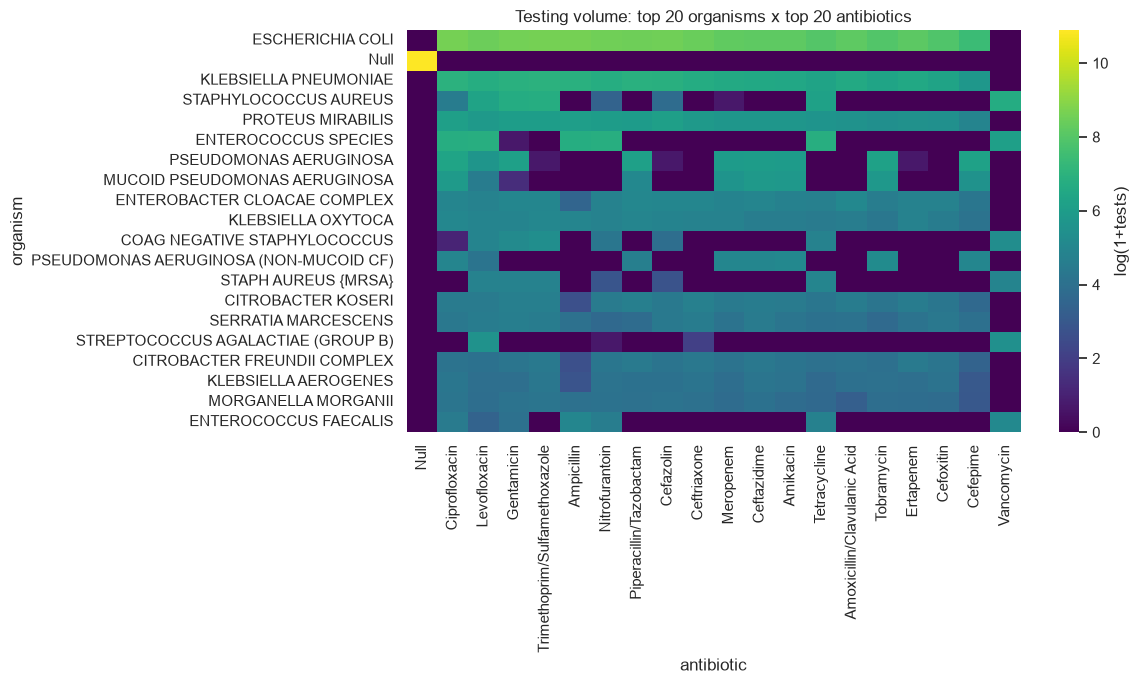

In [16]:
# organism x antibiotic testing matrix: how dense is the core bipartite structure?
pairs = cohort.groupby([ORG, ABX]).size()
n_o, n_a = cohort[ORG].nunique(), cohort[ABX].nunique()
print(f"observed organism-antibiotic pairs: {len(pairs):,} of {n_o*n_a:,} possible ({len(pairs)/(n_o*n_a):.1%})")

top_o = cohort[ORG].value_counts().head(20).index
top_a = cohort[ABX].value_counts().head(20).index
mat = (cohort[cohort[ORG].isin(top_o) & cohort[ABX].isin(top_a)]
       .groupby([ORG, ABX]).size().unstack(fill_value=0).reindex(index=top_o, columns=top_a))
plt.figure(figsize=(12, 7))
sns.heatmap(np.log1p(mat), cmap="viridis", cbar_kws={"label":"log(1+tests)"})
plt.title("Testing volume: top 20 organisms x top 20 antibiotics"); plt.tight_layout(); plt.show()

## Part 5 — Feature availability & quality

Which columns are actually populated enough to use as features. Config's rule is to avoid
one-hot identity features (they cap a GNN ~0.49 F1) and use real signals — labs, vitals,
demographics, ADI, timing. This checks they exist and aren't mostly null.


In [17]:
# Wide-table structure (labs / vitals): how many summary columns of each kind
def prefix_counts(cols):
    out = {}
    for c in cols:
        m = re.match(r"(Q25|Q75|median|first|last)_", c)
        if m: out[m.group(1)] = out.get(m.group(1), 0) + 1
    return out
for t in ["labs", "vitals"]:
    cs = cols_of(t)
    if cs: print(f"{t:7s}: {len(cs)} cols | {prefix_counts(cs)}")

labs   : 59 cols | {'Q75': 11, 'Q25': 11, 'median': 11, 'first': 11, 'last': 11}
vitals : 28 cols | {'Q25': 5, 'Q75': 5, 'median': 5, 'first': 5, 'last': 5}


In [18]:
# Null rates on median_ summary columns (usable vs mostly-empty)
for t in ["labs", "vitals"]:
    med = [c for c in cols_of(t) if c.startswith("median_")]
    if med:
        df = load(t, usecols=[CK] + med)
        nr = df[med].isna().mean().sort_values()
        print(f"\n{t} median_ null rates (best 8 / worst 8):")
        print(pd.concat([nr.head(8), nr.tail(8)]).round(3).to_string())


labs median_ null rates (best 8 / worst 8):
median_wbc              0.0
median_neutrophils      0.0
median_lymphocytes      0.0
median_hgb              0.0
median_plt              0.0
median_na               0.0
median_hco3             0.0
median_bun              0.0
median_hgb              0.0
median_plt              0.0
median_na               0.0
median_hco3             0.0
median_bun              0.0
median_cr               0.0
median_lactate          0.0
median_procalcitonin    0.0

vitals median_ null rates (best 8 / worst 8):
median_heartrate    0.0
median_resprate     0.0
median_temp         0.0
median_sysbp        0.0
median_diasbp       0.0
median_heartrate    0.0
median_resprate     0.0
median_temp         0.0
median_sysbp        0.0
median_diasbp       0.0


In [19]:
# Demographic & ADI coverage + distributions
demo = load("demographics", usecols=[PK, config.COLUMNS["age"], config.COLUMNS["gender"]])
adi  = load("adi", usecols=[PK] + find_cols("adi", "adi"))
for nm, df in [("demographics", demo), ("adi", adi)]:
    if df is not None: print(nm, "null rates:", df.isna().mean().round(3).to_dict())
if demo is not None:
    print("\nage bins:\n", demo[config.COLUMNS["age"]].value_counts(dropna=False))

demographics null rates: {'anon_id': 0.0, 'age': 0.0, 'gender': 0.0}
adi null rates: {'anon_id': 0.0, 'adi_score': 0.0, 'adi_state_rank': 0.0}

age bins:
 age
55-64 years    53953
65-74 years    51437
45-54 years    35079
35-44 years    25245
25-34 years    21080
18-24 years    13206
Name: count, dtype: int64


In [20]:
# Temporal-recency columns across tables (candidate time features)
for name in config.ARMD_TABLES:
    tc = find_cols(name, "time_to_culture", "days_culture", "days_to_culture")
    if tc:
        df = load(name, usecols=tc)
        if df is not None:
            print(f"\n{name}: {tc}")
            print(df.describe().round(1).to_string())


comorbidity: ['comorbidity_component_start_days_culture', 'comorbidity_component_end_days_culture']
       comorbidity_component_start_days_culture  comorbidity_component_end_days_culture
count                                  199983.0                                  3508.0
mean                                      923.7                                   402.9
std                                       995.2                                  1091.6
min                                         0.0                                 -4087.0
25%                                       156.0                                   -56.2
50%                                       572.0                                   125.0
75%                                      1377.0                                   878.0
max                                      8463.0                                  5337.0

procedures: ['procedure_time_to_culturetime']
       procedure_time_to_culturetime
count                  

## Part 6 — Candidate split strategies (how to make 'hospitals')

This is the core of *your* open question. Federated learning only pays off when clients are
**genuinely different** (non-IID). Here we compare several ways to split the data and score each
on: number of usable clients, size balance, and how much the **resistance rate varies across
clients** (the heterogeneity your topology-aware method would exploit). Pick the winner later.


In [21]:
# Build a working frame with a single binary resistance lens (just for measuring skew)
work = cohort[cohort[LABEL].isin(outcomes)].copy()
work["is_R"] = work[LABEL].isin(["Resistant","Intermediate"]).astype(int)

# --- derive candidate split columns ---
splits = {}

# 1) Ward (needs priority collapse; flags can overlap)
wcols = [config.WARD_FLAG_COLUMNS[w] for w in config.WARD_PRIORITY]
if all(c in cols_of("ward") for c in wcols):
    ward = load("ward", usecols=[CK] + wcols)
    conds = [ward[config.WARD_FLAG_COLUMNS[w]] == 1 for w in config.WARD_PRIORITY]
    ward["split_ward"] = np.select(conds, config.WARD_PRIORITY, default="NONE")
    work = work.merge(ward[[CK, "split_ward"]], on=CK, how="left")
    splits["ward"] = "split_ward"

# 2) Specimen type (top categories, rest -> Other)
cd = config.COLUMNS["culture_description"]
top = work[cd].value_counts().head(4).index
work["split_specimen"] = np.where(work[cd].isin(top), work[cd], "Other")
splits["specimen_type"] = "split_specimen"

# 3) Ordering mode
if "ordering_mode" in work.columns:
    work["split_ordermode"] = work["ordering_mode"].fillna("Unknown")
    splits["ordering_mode"] = "split_ordermode"

# 4) Age band
demo_pk = load("demographics", usecols=[PK, config.COLUMNS["age"]])
if demo_pk is not None:
    work = work.merge(demo_pk.drop_duplicates(PK), on=PK, how="left")
    work["split_age"] = work[config.COLUMNS["age"]].fillna("Unknown")
    splits["age_bin"] = "split_age"

# 5) ADI quartile
adi_col = (find_cols("adi", "adi_score") or find_cols("adi", "adi"))[:1]
if adi_col:
    adi_pk = load("adi", usecols=[PK] + adi_col).drop_duplicates(PK)
    work = work.merge(adi_pk, on=PK, how="left")
    try:
        work["split_adi"] = pd.qcut(work[adi_col[0]], 4, labels=["Q1","Q2","Q3","Q4"], duplicates="drop").astype("object").fillna("Unknown")
        splits["adi_quartile"] = "split_adi"
    except Exception as e:
        print("adi split skipped:", e)

# 6) Time (year from jittered timestamp)
tcol = config.KEYS["time"]
if tcol in cols_of("cohort"):
    t = load("cohort", usecols=[CK, tcol]).drop_duplicates(CK)
    t["split_year"] = pd.to_datetime(t[tcol], errors="coerce", utc=True).dt.year.astype("Int64").astype("object").fillna("Unknown")
    work = work.merge(t[[CK, "split_year"]], on=CK, how="left")
    splits["time_year"] = "split_year"

print("candidate split columns built:", list(splits.keys()))

adi split skipped: Function 'quantile' has no kernel matching input types (large_string)
candidate split columns built: ['ward', 'specimen_type', 'ordering_mode', 'age_bin', 'time_year']


In [22]:
MIN_CLIENT = 5000   # a client smaller than this is hard to train a GNN on; tune as you like

def score_split(col):
    g = work.groupby(col)["is_R"].agg(n="size", rate="mean")
    g = g[g.index.astype(str) != "NONE"]
    w = g["n"] / g["n"].sum()
    wmean = (w * g["rate"]).sum()
    weighted_std = float(np.sqrt((w * (g["rate"] - wmean) ** 2).sum()))   # non-IID strength
    return {"n_clients": int(len(g)),
            "usable_clients(>=MIN)": int((g["n"] >= MIN_CLIENT).sum()),
            "smallest_client": int(g["n"].min()),
            "largest_client": int(g["n"].max()),
            "size_ratio(max/min)": round(g["n"].max()/max(g["n"].min(),1), 1),
            "resist_rate_min": round(g["rate"].min(), 3),
            "resist_rate_max": round(g["rate"].max(), 3),
            "resist_rate_spread": round(g["rate"].max()-g["rate"].min(), 3),
            "non_iid_score(wstd)": round(weighted_std, 4)}

summary = pd.DataFrame({name: score_split(col) for name, col in splits.items()}).T
print("Higher non_iid_score + several usable_clients + not-too-extreme size_ratio = better split for FL.\n")
summary.sort_values("non_iid_score(wstd)", ascending=False)

Higher non_iid_score + several usable_clients + not-too-extreme size_ratio = better split for FL.



,n_clients,usable_clients(>=MIN),smallest_client,largest_client,size_ratio(max/min),resist_rate_min,resist_rate_max,resist_rate_spread,non_iid_score(wstd)
time_year,18.0,11.0,1.0,15412.0,15412.0,0.000,0.296,0.296,0.0467
specimen_type,3.0,3.0,14227.0,110682.0,7.8,0.177,0.285,0.107,0.0383
age_bin,7.0,3.0,2835.0,118748.0,41.9,0.184,0.304,0.120,0.0294
ordering_mode,3.0,3.0,6231.0,75788.0,12.2,0.165,0.210,0.045,0.0139
ward,1.0,1.0,44856.0,44856.0,1.0,0.186,0.186,0.000,0.0000


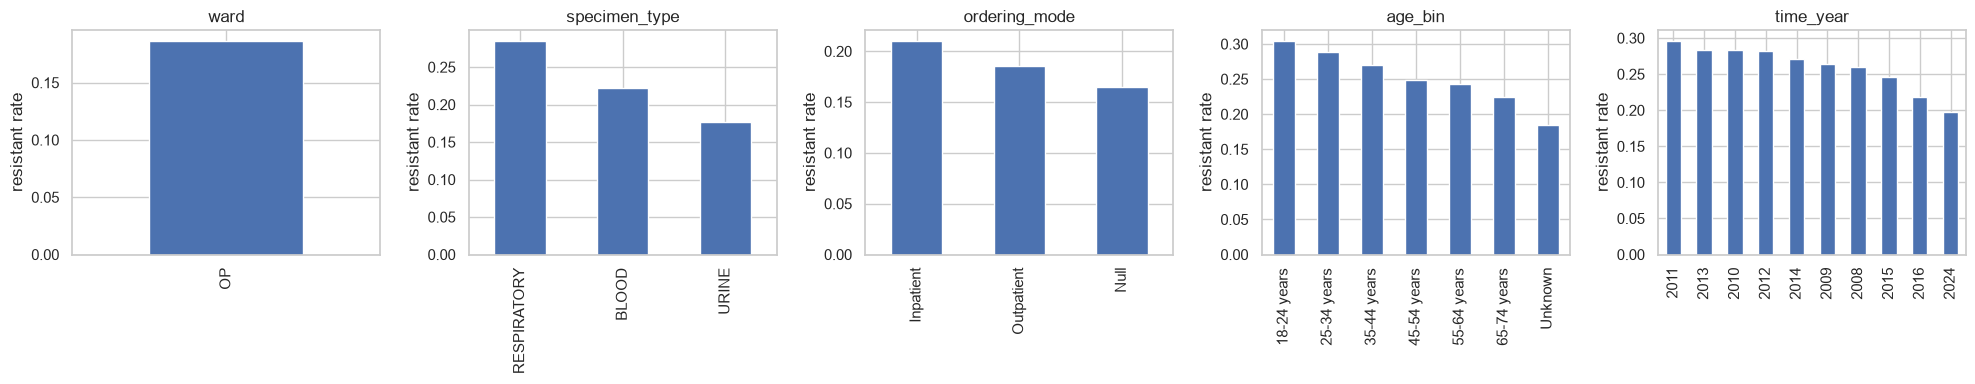

In [23]:
# Visual: resistance rate by client, for each candidate split
n = len(splits); fig, axes = plt.subplots(1, n, figsize=(4*n, 4), squeeze=False)
for ax, (name, col) in zip(axes[0], splits.items()):
    g = work.groupby(col)["is_R"].mean().sort_values(ascending=False)
    g = g[g.index.astype(str) != "NONE"].head(10)
    g.plot.bar(ax=ax, title=name); ax.set_ylabel("resistant rate"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## Part 7 — Per-partition structural preview

Once a split looks promising, this shows each client's graph shape — node counts, edges,
density, resistance rate. It's a generic function: change `chosen` to preview any split you like.


In [24]:
import networkx as nx
def preview(split_col):
    rows = []
    for cl, sub in work.groupby(split_col):
        if str(cl) == "NONE": continue
        G = nx.Graph()
        G.add_edges_from((("o",o),("a",a)) for o,a in sub[[ORG,ABX]].drop_duplicates().itertuples(index=False))
        ne, nn = G.number_of_edges(), G.number_of_nodes()
        rows.append({"client": cl, "tests": len(sub), "cultures": sub[CK].nunique(),
                     "patients": sub[PK].nunique(), "organisms": sub[ORG].nunique(),
                     "antibiotics": sub[ABX].nunique(), "org_abx_edges": ne,
                     "avg_degree": round(2*ne/max(nn,1),2), "density": round(nx.density(G),4),
                     "resistant_rate": round(sub["is_R"].mean(),3)})
    return pd.DataFrame(rows).set_index("client").sort_values("tests", ascending=False)

chosen = splits.get("ward") or list(splits.values())[0]   # <-- change to preview a different split
print("Previewing split column:", chosen)
preview(chosen)

Previewing split column: split_ward


,tests,cultures,patients,organisms,antibiotics,org_abx_edges,avg_degree,density,resistant_rate
client,,,,,,,,,
OP,44856,24353,16165,148,48,1042,10.63,0.0545,0.186


## Part 8 — Neutral readout (your call sheet)

Nothing above is locked. When you're ready to decide, these are the questions the outputs answer:

**Nodes** (Part 3) — which entities have enough distinct values *and* cross-patient sharing to be
worth a node; which are heavy-tailed enough to need an `Other` bucket or to stay as features.

**Edges** (Part 4) — which relationships are dense enough to matter; where the hub nodes are.

**Target** (Part 2) — binary R-vs-S, binary (R+I)-vs-S, or 3-class; and which rows to drop.
Whatever you pick, the imbalance means class weights + macro-F1, not accuracy.

**Split** (Part 6) — the axis with the strongest non-IID score that still yields a few
trainable-sized clients. If no split shows real heterogeneity, that's a finding too — it would
weaken the case for topology-aware aggregation, so you'd want to know now.

**Features** (Part 5) — the lab/vital/temporal columns that are actually populated.

Once you've made these calls, the next step is to encode them in `config.py` / `CLAUDE.md`,
then write `data_loader.py` and `graph_build.py` to match.
